In [1]:
import time
import torch
import torch.autograd as autograd
import pandas as pd
from itertools import product

torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Beam problem
# Governing equation:
#     E*I*u_xxxx = q
# Cantilever beam with uniform load q
# BCs:
#     u(0)=0, u'(0)=0, u''(L)=0, u'''(L)=0
# =========================================================

L = 1.0
q = -1.0

I_range = [0.9, 1.1]
E_range = [0.9, 1.1]

# =========================================================
# Exact solution
# =========================================================
def exact_solution(x, I, E):
    return q * x**2 * (6 * L**2 - 4 * L * x + x**2) / (24 * E * I)

# =========================================================
# Sampling methods
# =========================================================
def full_factorial_sampling_3d(n1, n2, n3, range1, range2, range3):
    a1 = torch.linspace(range1[0], range1[1], n1)
    a2 = torch.linspace(range2[0], range2[1], n2)
    a3 = torch.linspace(range3[0], range3[1], n3)
    pts = list(product(a1, a2, a3))
    return torch.tensor(pts, dtype=torch.float32)

def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

def monte_carlo_sampling(n, d):
    return torch.rand(n, d)

# =========================================================
# ELM setup
# =========================================================
hidden_size = 150
input_dim = 3

W = torch.randn(input_dim, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b) ** 2)

def trial_features(X):
    x = X[:, 0:1]
    return (x ** 2) * hidden_layer(X)

# =========================================================
# Build collocation points
# =========================================================
def generate_pde_points(method, n_x=10, n_I=10, n_E=10, n_pde=1000):
    if method == "Full Factorial":
        X_pde = full_factorial_sampling_3d(
            n_x, n_I, n_E,
            range1=(0.0, L),
            range2=(I_range[0], I_range[1]),
            range3=(E_range[0], E_range[1])
        )
    elif method == "LHS":
        lhs = latin_hypercube_sampling(n_pde, 3)
        x = lhs[:, 0:1] * L
        I = lhs[:, 1:2] * (I_range[1] - I_range[0]) + I_range[0]
        E = lhs[:, 2:3] * (E_range[1] - E_range[0]) + E_range[0]
        X_pde = torch.cat([x, I, E], dim=1)
    elif method == "Monte Carlo":
        mc = monte_carlo_sampling(n_pde, 3)
        x = mc[:, 0:1] * L
        I = mc[:, 1:2] * (I_range[1] - I_range[0]) + I_range[0]
        E = mc[:, 2:3] * (E_range[1] - E_range[0]) + E_range[0]
        X_pde = torch.cat([x, I, E], dim=1)
    else:
        raise ValueError("Unknown method")
    return X_pde.requires_grad_(True)

def generate_bc_points(method, n_bc_param=100):
    if method == "Full Factorial":
        n_side = int(n_bc_param ** 0.5)
        X_bc = full_factorial_sampling_3d(
            1, n_side, n_side,
            range1=(L, L),
            range2=(I_range[0], I_range[1]),
            range3=(E_range[0], E_range[1])
        )
    elif method == "LHS":
        lhs = latin_hypercube_sampling(n_bc_param, 2)
        x = torch.full((n_bc_param, 1), L)
        I = lhs[:, 0:1] * (I_range[1] - I_range[0]) + I_range[0]
        E = lhs[:, 1:2] * (E_range[1] - E_range[0]) + E_range[0]
        X_bc = torch.cat([x, I, E], dim=1)
    elif method == "Monte Carlo":
        mc = monte_carlo_sampling(n_bc_param, 2)
        x = torch.full((n_bc_param, 1), L)
        I = mc[:, 0:1] * (I_range[1] - I_range[0]) + I_range[0]
        E = mc[:, 1:2] * (E_range[1] - E_range[0]) + E_range[0]
        X_bc = torch.cat([x, I, E], dim=1)
    else:
        raise ValueError("Unknown method")
    return X_bc.requires_grad_(True)

# =========================================================
# Solve PIELM
# =========================================================
def solve_pielm(method, lambda_bc=50.0, reg=1e-6,
                n_x=10, n_I=10, n_E=10, n_pde=1000, n_bc_param=100):
    X_pde = generate_pde_points(method, n_x=n_x, n_I=n_I, n_E=n_E, n_pde=n_pde)
    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_pde, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        grad4 = autograd.grad(uj_xxx.sum(), X_pde, create_graph=True)[0]
        uj_xxxx = grad4[:, 0:1]

        I_vals = X_pde[:, 1:2]
        E_vals = X_pde[:, 2:3]

        A_cols.append(E_vals * I_vals * uj_xxxx)

    A = torch.hstack(A_cols)
    b_pde = torch.full((X_pde.shape[0], 1), q)

    X_bc = generate_bc_points(method, n_bc_param=n_bc_param)
    U_bc = trial_features(X_bc)

    C1_cols = []
    C2_cols = []

    for j in range(hidden_size):
        uj = U_bc[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_bc, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_bc, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_bc, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        C1_cols.append(uj_xx)
        C2_cols.append(uj_xxx)

    C1 = torch.hstack(C1_cols)
    C2 = torch.hstack(C2_cols)

    d1 = torch.zeros((X_bc.shape[0], 1))
    d2 = torch.zeros((X_bc.shape[0], 1))

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    A_T, C_T = A.T, C.T
    n_constraints = C.shape[0]

    KKT = torch.zeros(hidden_size + n_constraints, hidden_size + n_constraints)
    KKT[:hidden_size, :hidden_size] = A_T @ A + reg * torch.eye(hidden_size)
    KKT[:hidden_size, hidden_size:] = lambda_bc * C_T
    KKT[hidden_size:, :hidden_size] = lambda_bc * C

    rhs = torch.vstack([A_T @ b_pde, lambda_bc * d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]

    return beta, X_pde.shape[0], X_bc.shape[0]

def predict(X, beta):
    return trial_features(X) @ beta

# =========================================================
# Evaluation metrics
# =========================================================
def evaluate_method(method, I_test=1.0, E_test=1.0, n_test=200):
    start_train = time.perf_counter()
    beta, n_pde_pts, n_bc_pts = solve_pielm(method)
    train_time = time.perf_counter() - start_train

    x_test = torch.linspace(0, L, n_test).reshape(-1, 1)
    I_vec = torch.full_like(x_test, I_test)
    E_vec = torch.full_like(x_test, E_test)
    X_test = torch.cat([x_test, I_vec, E_vec], dim=1)

    start_pred = time.perf_counter()
    u_pred = predict(X_test, beta).detach().squeeze()
    pred_time = time.perf_counter() - start_pred

    u_exact = exact_solution(x_test, I_vec, E_vec).detach().squeeze()

    eps = 1e-12
    abs_error = torch.abs(u_pred - u_exact)
    rel_l2 = (torch.norm(u_pred - u_exact) / (torch.norm(u_exact) + eps)).item()
    rmse = torch.sqrt(torch.mean((u_pred - u_exact) ** 2)).item()
    max_abs = torch.max(abs_error).item()
    mean_abs = torch.mean(abs_error).item()

    return {
        "Method": method,
        "PDE Points": n_pde_pts,
        "BC Points": n_bc_pts,
        "Relative L2 Error": rel_l2,
        "RMSE": rmse,
        "Max Absolute Error": max_abs,
        "Mean Absolute Error": mean_abs,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
    }

# =========================================================
# Compare all three methods
# =========================================================
methods = ["Full Factorial", "LHS", "Monte Carlo"]
results = [evaluate_method(m) for m in methods]

df = pd.DataFrame(results)

# Optional formatting
pd.set_option("display.float_format", "{:.6e}".format)

print("\nComparison of Sampling Methods for PIELM")
print(df.to_string(index=False))


Comparison of Sampling Methods for PIELM
        Method  PDE Points  BC Points  Relative L2 Error         RMSE  Max Absolute Error  Mean Absolute Error  Training Time (s)  Prediction Time (s)
Full Factorial        1000        100       1.702822e-02 1.081182e-03        2.152443e-03         8.439895e-04       9.033562e-01         1.116250e-04
           LHS        1000        100       2.441974e-04 1.550496e-05        3.197789e-05         1.193696e-05       8.321532e-01         6.579200e-05
   Monte Carlo        1000        100       1.053292e-04 6.687729e-06        1.361966e-05         5.198385e-06       1.068923e+00         6.058400e-05



Comparison of Sampling Methods for PIELM
        Method  PDE Points  BC Points  Relative L2 Error         RMSE  Max Absolute Error  Mean Absolute Error  Training Time (s)  Prediction Time (s)
Full Factorial        1000        100       3.765044e-03 3.824898e-03        7.797718e-03         2.962057e-03       1.224598e+00         2.179917e-03
           LHS        1000        100       7.017495e-04 7.129054e-04        1.423359e-03         5.576674e-04       1.159306e+00         9.116699e-05
   Monte Carlo        1000        100       1.648959e-02 1.675173e-02        3.372955e-02         1.306564e-02       1.101544e+00         9.270804e-05


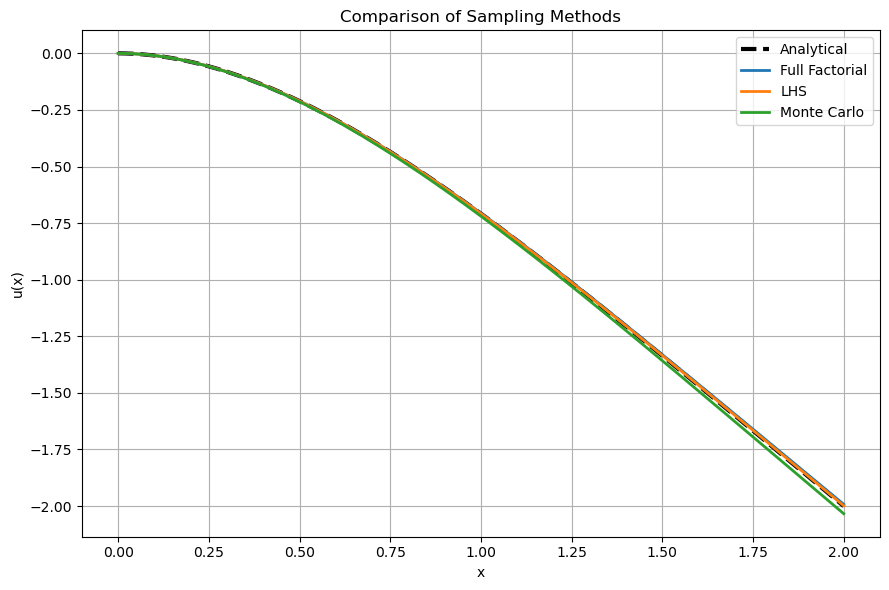

In [3]:
import time
import torch
import torch.autograd as autograd
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

#torch.manual_seed(0)
torch.set_default_dtype(torch.float32)

# =========================================================
# Beam problem
# Governing equation:
#     E*I*u_xxxx = q
# Cantilever beam with uniform load q
# BCs:
#     u(0)=0, u'(0)=0, u''(L)=0, u'''(L)=0
# =========================================================

L = 2.0
q = -1.0

I_range = [0.9, 1.1]
E_range = [0.9, 1.1]

# =========================================================
# Exact solution
# =========================================================
def exact_solution(x, I, E):
    return q * x**2 * (6 * L**2 - 4 * L * x + x**2) / (24 * E * I)

# =========================================================
# Sampling methods
# =========================================================
def full_factorial_sampling_3d(n1, n2, n3, range1, range2, range3):
    a1 = torch.linspace(range1[0], range1[1], n1)
    a2 = torch.linspace(range2[0], range2[1], n2)
    a3 = torch.linspace(range3[0], range3[1], n3)
    pts = list(product(a1, a2, a3))
    return torch.tensor(pts, dtype=torch.float32)

def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

def monte_carlo_sampling(n, d):
    return torch.rand(n, d)

# =========================================================
# ELM setup
# =========================================================
hidden_size = 150
input_dim = 3

W = torch.randn(input_dim, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b) ** 2)

def trial_features(X):
    x = X[:, 0:1]
    return (x ** 2) * hidden_layer(X)

# =========================================================
# Generate PDE collocation points
# =========================================================
def generate_pde_points(method, n_x=10, n_I=10, n_E=10, n_pde=1000):
    if method == "Full Factorial":
        X_pde = full_factorial_sampling_3d(
            n_x, n_I, n_E,
            range1=(0.0, L),
            range2=(I_range[0], I_range[1]),
            range3=(E_range[0], E_range[1])
        )
    elif method == "LHS":
        lhs = latin_hypercube_sampling(n_pde, 3)
        x = lhs[:, 0:1] * L
        I = lhs[:, 1:2] * (I_range[1] - I_range[0]) + I_range[0]
        E = lhs[:, 2:3] * (E_range[1] - E_range[0]) + E_range[0]
        X_pde = torch.cat([x, I, E], dim=1)
    elif method == "Monte Carlo":
        mc = monte_carlo_sampling(n_pde, 3)
        x = mc[:, 0:1] * L
        I = mc[:, 1:2] * (I_range[1] - I_range[0]) + I_range[0]
        E = mc[:, 2:3] * (E_range[1] - E_range[0]) + E_range[0]
        X_pde = torch.cat([x, I, E], dim=1)
    else:
        raise ValueError("Unknown method. Choose 'Full Factorial', 'LHS', or 'Monte Carlo'.")
    return X_pde.requires_grad_(True)

# =========================================================
# Generate BC points at x = L
# =========================================================
def generate_bc_points(method, n_bc_param=100):
    if method == "Full Factorial":
        n_side = int(n_bc_param ** 0.5)
        X_bc = full_factorial_sampling_3d(
            1, n_side, n_side,
            range1=(L, L),
            range2=(I_range[0], I_range[1]),
            range3=(E_range[0], E_range[1])
        )
    elif method == "LHS":
        lhs = latin_hypercube_sampling(n_bc_param, 2)
        x = torch.full((n_bc_param, 1), L)
        I = lhs[:, 0:1] * (I_range[1] - I_range[0]) + I_range[0]
        E = lhs[:, 1:2] * (E_range[1] - E_range[0]) + E_range[0]
        X_bc = torch.cat([x, I, E], dim=1)
    elif method == "Monte Carlo":
        mc = monte_carlo_sampling(n_bc_param, 2)
        x = torch.full((n_bc_param, 1), L)
        I = mc[:, 0:1] * (I_range[1] - I_range[0]) + I_range[0]
        E = mc[:, 1:2] * (E_range[1] - E_range[0]) + E_range[0]
        X_bc = torch.cat([x, I, E], dim=1)
    else:
        raise ValueError("Unknown method. Choose 'Full Factorial', 'LHS', or 'Monte Carlo'.")
    return X_bc.requires_grad_(True)

# =========================================================
# Solve PIELM
# =========================================================
def solve_pielm(
    method,
    lambda_bc=50.0,
    reg=1e-6,
    n_x=10,
    n_I=10,
    n_E=10,
    n_pde=1000,
    n_bc_param=100
):
    X_pde = generate_pde_points(
        method,
        n_x=n_x,
        n_I=n_I,
        n_E=n_E,
        n_pde=n_pde
    )

    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_pde, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_pde, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_pde, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        grad4 = autograd.grad(uj_xxx.sum(), X_pde, create_graph=True)[0]
        uj_xxxx = grad4[:, 0:1]

        I_vals = X_pde[:, 1:2]
        E_vals = X_pde[:, 2:3]

        A_cols.append(E_vals * I_vals * uj_xxxx)

    A = torch.hstack(A_cols)
    b_pde = torch.full((X_pde.shape[0], 1), q)

    X_bc = generate_bc_points(method, n_bc_param=n_bc_param)
    U_bc = trial_features(X_bc)

    C1_cols = []
    C2_cols = []

    for j in range(hidden_size):
        uj = U_bc[:, j:j+1]

        grad1 = autograd.grad(uj.sum(), X_bc, create_graph=True)[0]
        uj_x = grad1[:, 0:1]

        grad2 = autograd.grad(uj_x.sum(), X_bc, create_graph=True)[0]
        uj_xx = grad2[:, 0:1]

        grad3 = autograd.grad(uj_xx.sum(), X_bc, create_graph=True)[0]
        uj_xxx = grad3[:, 0:1]

        C1_cols.append(uj_xx)   # u''(L)=0
        C2_cols.append(uj_xxx)  # u'''(L)=0

    C1 = torch.hstack(C1_cols)
    C2 = torch.hstack(C2_cols)

    d1 = torch.zeros((X_bc.shape[0], 1))
    d2 = torch.zeros((X_bc.shape[0], 1))

    C = torch.vstack([C1, C2])
    d = torch.vstack([d1, d2])

    A_T = A.T
    C_T = C.T
    n_constraints = C.shape[0]

    KKT = torch.zeros(hidden_size + n_constraints, hidden_size + n_constraints)
    KKT[:hidden_size, :hidden_size] = A_T @ A + reg * torch.eye(hidden_size)
    KKT[:hidden_size, hidden_size:] = lambda_bc * C_T
    KKT[hidden_size:, :hidden_size] = lambda_bc * C

    rhs = torch.vstack([A_T @ b_pde, lambda_bc * d])

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:hidden_size]

    return beta, X_pde.shape[0], X_bc.shape[0]

def predict(X, beta):
    return trial_features(X) @ beta

# =========================================================
# Evaluate one method
# =========================================================
def evaluate_method(method, I_test=1.0, E_test=1.0, n_test=200):
    start_train = time.perf_counter()
    beta, n_pde_pts, n_bc_pts = solve_pielm(method)
    train_time = time.perf_counter() - start_train

    x_test = torch.linspace(0, L, n_test).reshape(-1, 1)
    I_vec = torch.full_like(x_test, I_test)
    E_vec = torch.full_like(x_test, E_test)
    X_test = torch.cat([x_test, I_vec, E_vec], dim=1)

    start_pred = time.perf_counter()
    u_pred = predict(X_test, beta).detach().squeeze()
    pred_time = time.perf_counter() - start_pred

    u_exact = exact_solution(x_test, I_vec, E_vec).detach().squeeze()

    eps = 1e-12
    abs_error = torch.abs(u_pred - u_exact)
    rel_l2 = (torch.norm(u_pred - u_exact) / (torch.norm(u_exact) + eps)).item()
    rmse = torch.sqrt(torch.mean((u_pred - u_exact) ** 2)).item()
    max_abs = torch.max(abs_error).item()
    mean_abs = torch.mean(abs_error).item()

    return {
        "Method": method,
        "PDE Points": n_pde_pts,
        "BC Points": n_bc_pts,
        "Relative L2 Error": rel_l2,
        "RMSE": rmse,
        "Max Absolute Error": max_abs,
        "Mean Absolute Error": mean_abs,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
        "x": x_test.detach().squeeze(),
        "prediction": u_pred,
        "exact": u_exact
    }

# =========================================================
# Run comparison
# =========================================================
methods = ["Full Factorial", "LHS", "Monte Carlo"]

results = []
predictions = {}
x_plot_store = None
u_exact_store = None

for method in methods:
    res = evaluate_method(method)
    results.append(res)
    predictions[method] = res["prediction"]
    x_plot_store = res["x"]
    u_exact_store = res["exact"]

# =========================================================
# Create and print comparison table
# =========================================================
df = pd.DataFrame(results)
df = df.drop(columns=["x", "prediction", "exact"])

pd.set_option("display.float_format", "{:.6e}".format)

print("\nComparison of Sampling Methods for PIELM")
print(df.to_string(index=False))

# =========================================================
# Plot comparison of all three methods with analytical solution
# =========================================================
plt.figure(figsize=(9, 6))

plt.plot(
    x_plot_store.numpy(),
    u_exact_store.numpy(),
    'k--',
    linewidth=3,
    label="Analytical"
)

for method in methods:
    plt.plot(
        x_plot_store.numpy(),
        predictions[method].numpy(),
        linewidth=2,
        label=method
    )

plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Comparison of Sampling Methods")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Results:


,Method,Neurons,PDE Points,Error,Time
0,Full Factorial,50,200,1.799527,0.198741
1,Full Factorial,100,200,1.454530,0.528314
2,Full Factorial,150,200,1.295427,0.998618
3,Full Factorial,50,500,1.620001,0.232950
4,Full Factorial,100,500,1.232100,0.573832
5,Full Factorial,150,500,1.248383,1.039622
6,Full Factorial,50,1000,1.874216,0.253079
7,Full Factorial,100,1000,1.359431,0.584412
8,Full Factorial,150,1000,1.415540,0.933920
9,LHS,50,200,1.752004,0.047276


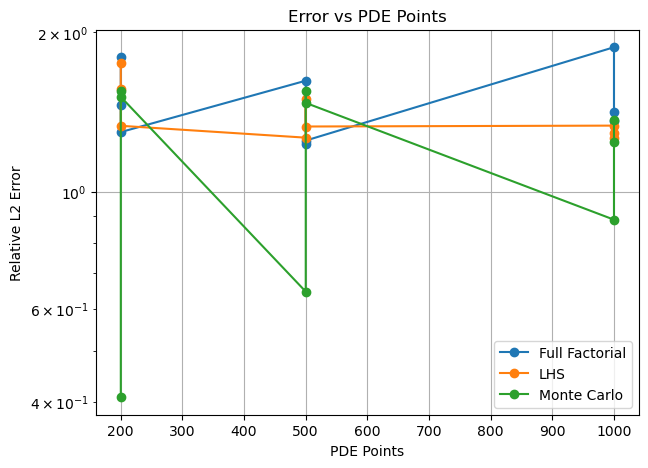

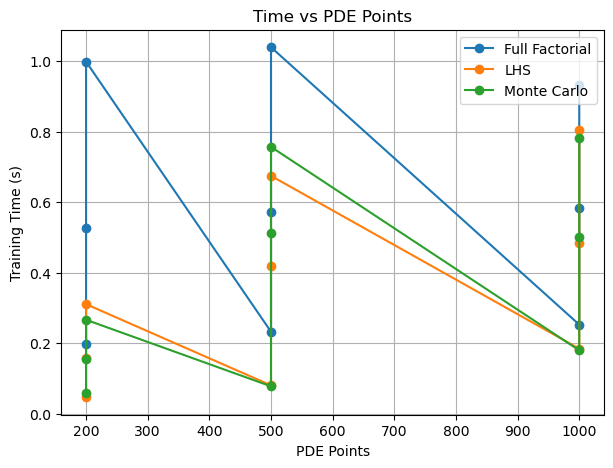


Saved results to pielm_results.csv


In [2]:
# ============================
# PIELM Beam Sweep (All-in-One)
# ============================

# Optional: inline plots
%matplotlib inline

import time
import torch
import torch.autograd as autograd
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

torch.set_default_dtype(torch.float32)

# ----------------------------
# Problem definition
# ----------------------------
L = 2.0
q = -1.0
I_range = [0.9, 1.1]
E_range = [0.9, 1.1]

input_dim = 3
hidden_size = 150

# ----------------------------
# Exact solution
# ----------------------------
def exact_solution(x, I, E):
    return q * x**2 * (6 * L**2 - 4 * L * x + x**2) / (24 * E * I)

# ----------------------------
# Sampling
# ----------------------------
def full_factorial_sampling_3d(n1, n2, n3, r1, r2, r3):
    a1 = torch.linspace(r1[0], r1[1], n1)
    a2 = torch.linspace(r2[0], r2[1], n2)
    a3 = torch.linspace(r3[0], r3[1], n3)
    pts = list(product(a1, a2, a3))
    return torch.tensor(pts, dtype=torch.float32)

def latin_hypercube_sampling(n, d):
    H = torch.zeros(n, d)
    for j in range(d):
        perm = torch.randperm(n)
        H[:, j] = (perm + torch.rand(n)) / n
    return H

def monte_carlo_sampling(n, d):
    return torch.rand(n, d)

# ----------------------------
# ELM setup
# ----------------------------
def reset_elm(new_hidden_size):
    global hidden_size, W, b
    hidden_size = new_hidden_size
    W = torch.randn(input_dim, hidden_size)
    b = torch.randn(hidden_size)

reset_elm(hidden_size)

def hidden_layer(X):
    return torch.exp(-(X @ W + b) ** 2)

def trial_features(X):
    x = X[:, 0:1]
    return (x ** 2) * hidden_layer(X)

# ----------------------------
# Point generators
# ----------------------------
def generate_pde_points(method, n_x=10, n_I=10, n_E=10, n_pde=1000):
    if method == "Full Factorial":
        X = full_factorial_sampling_3d(
            n_x, n_I, n_E,
            (0.0, L),
            (I_range[0], I_range[1]),
            (E_range[0], E_range[1])
        )
    elif method == "LHS":
        lhs = latin_hypercube_sampling(n_pde, 3)
        x = lhs[:, 0:1] * L
        I = lhs[:, 1:2] * (I_range[1] - I_range[0]) + I_range[0]
        E = lhs[:, 2:3] * (E_range[1] - E_range[0]) + E_range[0]
        X = torch.cat([x, I, E], dim=1)
    elif method == "Monte Carlo":
        mc = monte_carlo_sampling(n_pde, 3)
        x = mc[:, 0:1] * L
        I = mc[:, 1:2] * (I_range[1] - I_range[0]) + I_range[0]
        E = mc[:, 2:3] * (E_range[1] - E_range[0]) + E_range[0]
        X = torch.cat([x, I, E], dim=1)
    else:
        raise ValueError("Unknown method")
    return X.requires_grad_(True)

# ----------------------------
# Solver (fast LS version)
# ----------------------------
def solve_pielm(method, n_x=10, n_I=10, n_E=10, n_pde=1000):
    X_pde = generate_pde_points(method, n_x, n_I, n_E, n_pde)
    U = trial_features(X_pde)

    A_cols = []
    for j in range(hidden_size):
        uj = U[:, j:j+1]

        g1 = autograd.grad(uj.sum(), X_pde, create_graph=True)[0][:, 0:1]
        g2 = autograd.grad(g1.sum(), X_pde, create_graph=True)[0][:, 0:1]
        g3 = autograd.grad(g2.sum(), X_pde, create_graph=True)[0][:, 0:1]
        g4 = autograd.grad(g3.sum(), X_pde, create_graph=True)[0][:, 0:1]

        EI = X_pde[:, 1:2] * X_pde[:, 2:3]
        A_cols.append(EI * g4)

    A = torch.hstack(A_cols)
    b = torch.full((X_pde.shape[0], 1), q)

    beta = torch.linalg.lstsq(A, b).solution
    return beta

# ----------------------------
# Evaluation
# ----------------------------
def evaluate(method, neurons, n_pde):
    reset_elm(neurons)

    t0 = time.perf_counter()
    beta = solve_pielm(method, n_pde=n_pde)
    train_time = time.perf_counter() - t0

    x = torch.linspace(0, L, 200).reshape(-1, 1)
    I = torch.ones_like(x)
    E = torch.ones_like(x)
    X = torch.cat([x, I, E], dim=1)

    u_pred = (trial_features(X) @ beta).detach().squeeze()
    u_exact = exact_solution(x, I, E).squeeze()

    rel_err = (torch.norm(u_pred - u_exact) / torch.norm(u_exact)).item()

    return rel_err, train_time

# ----------------------------
# Experiments
# ----------------------------
methods = ["Full Factorial", "LHS", "Monte Carlo"]

# Start small → increase later if needed
neurons_list = [50, 100, 150]
pde_list = [200, 500, 1000]

rows = []

for method in methods:
    for n_pde in pde_list:
        for neurons in neurons_list:

            # Fix Full Factorial scaling
            if method == "Full Factorial":
                n_side = max(2, round(n_pde ** (1/3)))
                err, t = evaluate(method, neurons, n_side**3)
            else:
                err, t = evaluate(method, neurons, n_pde)

            rows.append({
                "Method": method,
                "Neurons": neurons,
                "PDE Points": n_pde,
                "Error": err,
                "Time": t
            })

df_sweep = pd.DataFrame(rows)

print("\nResults:")
display(df_sweep)

# ----------------------------
# Plot: Error
# ----------------------------
plt.figure(figsize=(7,5))
for method in methods:
    temp = df_sweep[df_sweep["Method"] == method]
    plt.plot(temp["PDE Points"], temp["Error"], marker="o", label=method)

plt.yscale("log")
plt.xlabel("PDE Points")
plt.ylabel("Relative L2 Error")
plt.title("Error vs PDE Points")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Plot: Time
# ----------------------------
plt.figure(figsize=(7,5))
for method in methods:
    temp = df_sweep[df_sweep["Method"] == method]
    plt.plot(temp["PDE Points"], temp["Time"], marker="o", label=method)

plt.xlabel("PDE Points")
plt.ylabel("Training Time (s)")
plt.title("Time vs PDE Points")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Save results
# ----------------------------
df_sweep.to_csv("pielm_results.csv", index=False)
print("\nSaved results to pielm_results.csv")